In [1]:
here::i_am("revisions/downsample/downsample.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [2]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA"

In [3]:
args = list()
args$meta = file.path(io$basedir, 'results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz')
args$sce = io$rna.sce

args$outdir = file.path(io$basedir, 'results/rna/revisions/downsample/')
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

In [4]:
meta <- fread(args$meta) %>% 
  .[pass_rnaQC==TRUE & doublet_score <= 0.5]

In [5]:
sce = readRDS(args$sce)[, meta$cell]

In [6]:
sce

class: SingleCellExperiment 
dim: 29453 28723 
metadata(0):
assays(1): counts
rownames(29453): Xkr4 Gm1992 ... CAAA01147332.1 tomato-td
rowData names(0):
colnames(28723): SLX-20795_SITTA11_HKTG2DRXY#AAACCCAGTTCTCTAT-1
  SLX-20795_SITTA11_HKTG2DRXY#AAACGCTAGTGATTCC-1 ...
  SLX-20795_SITTH11_HKTG2DRXY#TTTGTTGCAATGAGCG-1
  SLX-20795_SITTH11_HKTG2DRXY#TTTGTTGCATATGCGT-1
colData names(12): sample barcode ... pass_rnaQC sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [7]:
sparse_matrix = counts(sce)

In [8]:
# Calculate total reads per cell (column sums)
cell_counts <- colSums(sparse_matrix)

# Define the target count as the minimum count among all cells
target_count <- min(cell_counts)

# Function to downsample a cell to the target count
downsample_cell <- function(cell, target_count) {
  # Repeat each gene index according to its read count
  gene_indices <- rep(seq_along(cell), times = cell)
  
  # Randomly sample indices to reach the target count
  sampled_indices <- sample(gene_indices, target_count, replace = FALSE)
  
  # Tabulate the sampled indices to get the downsampled gene counts
  downsampled_counts <- tabulate(sampled_indices, nbins = length(cell))
  
  return(downsampled_counts)
}
a = Sys.time()
downsampled_matrix_list <- mclapply(1:ncol(sparse_matrix), function(j) { # ncol(sparse_matrix)
  downsample_cell(sparse_matrix[, j], target_count)
}, mc.cores = 36)

# Combine the result back into a matrix
downsampled_matrix <- do.call(cbind, downsampled_matrix_list)
downsampled_matrix <- Matrix::Matrix(downsampled_matrix, sparse = TRUE)

b = Sys.time()
b - a

Time difference of 1.183029 mins

In [9]:
rownames(downsampled_matrix) = rownames(sparse_matrix)
colnames(downsampled_matrix) = colnames(sparse_matrix)

In [10]:
# Create SCE object
sce_query = SingleCellExperiment(downsampled_matrix)

colData(sce_query) <- meta %>% tibble::column_to_rownames("cell") %>% DataFrame

In [11]:
assayNames(sce_query) = 'counts' 

In [12]:
sce_orig = sce_query

## Mapping to atlas

In [13]:
# Load packages
suppressPackageStartupMessages({
    library(dplyr)
    library(data.table)
    library(ggplot2)
    library(SingleCellExperiment)
    library(scater)
    library(scran)
    library(edgeR)
    library(ggrastr)
    library(batchelor)
})

here::i_am("mapping/run/01_mapping_manual.ipynb")

# Load mapping functions
source(here::here("mapping/run/mnn/mapping_functions_extended.R"))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [14]:
args$atlas_sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/processed/SingleCellExperiment.rds'
args$atlas_metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz'
args$atlas_stages = c('E7.5', 'E7.75', 'E8.0', 'E8.25', 'E8.5')
args$npcs = 40
args$n_neighbours = 15
args$cosine_normalisation = FALSE

In [15]:
sce_query = logNormCounts(sce_query)

In [16]:
meta_query = meta

In [17]:
################
## Load atlas ##
################

# Load cell metadata
meta_atlas <- fread(args$atlas_metadata) %>%
  .[stage%in%args$atlas_stages] %>%
  .[,sample:=factor(sample)] 

# Filter
if (isTRUE(args$test)) meta_atlas <- head(meta_atlas,n=1000)

# Load SingleCellExperiment
sce_atlas <- load_SingleCellExperiment(args$atlas_sce, normalise = TRUE, cells = meta_atlas$cell, remove_non_expressed_genes = TRUE)

# Update colData
tmp <- meta_atlas %>% .[cell%in%colnames(sce_atlas)] %>% setkey(cell) %>% .[colnames(sce_atlas)]
stopifnot(tmp$cell == colnames(sce_atlas))
colData(sce_atlas) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_atlas),] %>% DataFrame()

# Sanity cehcks
stopifnot(sum(is.na(rownames(sce_atlas)))==0)
stopifnot(sum(duplicated(rownames(sce_atlas)))==0)

In [18]:
#####################
## Define gene set ##
#####################

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id%in%rownames(sce_atlas)] %>%
  .[!duplicated(symbol)]

rownames(sce_atlas) = gene_metadata[match(rownames(sce_atlas), ens_id), symbol]

In [19]:
# Imprinted genes
imprint = gene_metadata[c(grep('maternally', gene_metadata$description),
                       grep('paternally', gene_metadata$description)), symbol]
#Other imprinted genes: 
#- Nnat (https://www.genecards.org/cgi-bin/carddisp.pl?gene=NNAT)
#- Grb10 (https://www.genecards.org/cgi-bin/carddisp.pl?gene=GRB10)

# Intersect genes
genes.intersect <- intersect(rownames(sce_query), rownames(sce_atlas))

# Filter some genes manually
genes.intersect <- genes.intersect[grep("^Rik|Rik$|^mt-|^Rps|^Rpl|^Gm",genes.intersect,invert=T)] # filter out non-informative genes
genes.intersect <- genes.intersect[grep("^Hbb|^Hba",genes.intersect,invert=T)] # test removing Haem genes 
genes.intersect <- genes.intersect[!genes.intersect %in% c(imprint, 'Grb10', 'Nnat')] # remove imprinted genes
genes.intersect <- genes.intersect[!genes.intersect %in% c("Xist", "Tsix")] # remove Xist & Tsix
genes.intersect <- genes.intersect[!genes.intersect=="tomato-td"] # remove tomato itself
genes.intersect <- genes.intersect[!genes.intersect %in% gene_metadata[chr=="chrY",symbol]] # no genes on y-chr 

# Subset SingleCellExperiment objects
sce_query  <- sce_query[genes.intersect,]
sce_atlas <- sce_atlas[genes.intersect,]

In [20]:
#######################
## Feature selection ##
#######################

# Load gene statistics from the atlas
gene_stats.dt <- fread(paste0(io$atlas.basedir,"/results/gene_statistics/gene_statistics.txt.gz")) %>%
.[gene%in%genes.intersect]
genes_to_use <- gene_stats.dt %>% setorder(-var_pseudobulk, na.last = T) %>% head(n=4000) %>% .$gene  

stopifnot(genes_to_use%in%rownames(sce_atlas))
stopifnot(genes_to_use%in%rownames(sce_query))

sce_query = sce_query[genes_to_use,]
sce_atlas = sce_atlas[genes_to_use,]

In [21]:
mapping_full = mclapply(unique(meta_query$sample), function(x){
    mapping  <- mapWrap(
          sce_atlas = sce_atlas,
          meta_atlas = meta_atlas,
          sce_query = sce_query[,meta_query[sample==x, cell]],
          meta_query = meta_query[sample==x, ],
          genes = genes_to_use,
          npcs = args$npcs,
          k = args$n_neighbours,
          cosineNorm = args$cosine_normalisation,
          order = NULL
        )
    
    mapping.dt <- mapping$mapping %>% 
      .[,c("cell","celltype.mapped","celltype.score","celltype_extended.mapped","celltype_extended.score","stage.mapped", "cellstage.score", "closest.cell")] %>% 
      as.data.table
    
    return(mapping.dt)
}, mc.cores=4)

In [22]:
mapping_full = mapping_full %>% rbindlist()

In [23]:
mapping_full = mapping_full %>% setnames(colnames(mapping_full)[-1], paste0(colnames(mapping_full)[-1], '_mnn'))

In [24]:
meta_full = merge(meta_query, mapping_full, by='cell') %>% 
    .[match(colnames(sce_query), cell)]

## Update annotation

In [25]:
original_keep = c('Allantois', 
                  paste0('Blood_progenitors_', 1:2),
                  'Cardiomyocytes',
                  'Caudal_epiblast',
                  'Caudal_Mesoderm',
                  'Caudal_neurectoderm',
                  'Def._endoderm',
                  'Epiblast',
                  'ExE_ectoderm',
                  'ExE_endoderm',
                  'Forebrain_Midbrain_Hindbrain',
                  'Gut',
                  'Nascent_mesoderm',
                  'Neural_crest',
                  'NMP',
                  'Notochord', 
                  'Parietal_endoderm',
                  'PGC',
                  'Pharyngeal_mesoderm',
                  'Rostral_neurectoderm', 
                  'Spinal_cord',
                  'Surface_ectoderm', # Except for amniotic ectoderm
                  'Visceral_endoderm'                  
                )
original_replace = c('Endothelium',
                    paste0('Erythroid', 1:3), # --> Erythroid
                    'ExE_mesoderm', # --> Replace with LPM all together
                     'Haematoendothelial_progenitors',# --> Use exteended atlas label
                   'Mixed_mesoderm' # Use the new labels as they are more precise
                )


In [26]:
meta_full = meta_full[,celltype_updated := celltype.mapped_mnn] %>% 
    # Add higher resolution endothelium annotation
    .[,celltype_updated := ifelse(celltype_updated %in% c('Endothelium', 'Haematoendothelial_progenitors'), celltype_extended.mapped_mnn, celltype_updated), ] %>% 
    # Merge Erythroids 
    .[,celltype_updated := ifelse(celltype_updated %in% paste0('Erythroid', 1:3), 'Erythroid', celltype_updated)] %>%
    # Change 'ExE mesoderm' to 'Lateral plate mesoderm'
    .[,celltype_updated := ifelse(celltype_updated == 'ExE_mesoderm', 'Lateral_plate_mesoderm', celltype_updated)] %>% 
    # Improve mixed mesoderm annotation
    .[,celltype_updated := ifelse(celltype_updated == 'Mixed_mesoderm', celltype_extended.mapped_mnn, celltype_updated)] %>% 
    # Add amniotic ectoderm    
    .[,celltype_updated := ifelse(celltype_extended.mapped_mnn == 'Amniotic_ectoderm', 'Amniotic_ectoderm', celltype_updated)] %>%
    # Add YS mesothelium
    .[,celltype_updated := ifelse(celltype_extended.mapped_mnn == 'YS_mesothelium', 'YS_mesothelium', celltype_updated)]

In [27]:
fwrite(meta_full, paste0(args$outdir, 'metadata_mapping_updated.txt.gz'))

## Differential Expression

In [28]:
# Load packages
suppressPackageStartupMessages({
    library(dplyr)
    library(data.table)
    library(ggplot2)
    library(SingleCellExperiment)
    library(scater)
    library(scran)
    library(edgeR)
    library(ggrastr)
})

here::i_am("differential/01_DEG_analysis_manual.ipynb")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [29]:
args$variable = 'celltype_updated'

In [30]:
# Functions
# Plotting function
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=20, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = de.results[variable == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot[!is.na(sig)])
  to.plot = to.plot[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>%
               .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC_plot, y=log10_padj_fdr)) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*1.05), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim*1.16)) +
    annotate("text", x=0, y=ylim*1.1, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC_plot, y=log10_padj_fdr, label=gene), 
                                     max.overlaps=Inf, 
                                     box.padding = 0.5,
                                     bg.color='white', 
                                     bg.r = 0.1,
                                     size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
    
    
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

In [31]:
###############
## Load data ##
###############

# Load metadata
sample_metadata <- meta_full %>%
   .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)] %>% 
   .[,variable := .[[args$variable]]]

# Load RNA expression data as SingleCellExperiment object
sce <- sce_orig

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [32]:
nrow(sample_metadata)

[1] 28723

In [33]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(sce, 
    id=colData(sce)[,c("variable", "sample", "tdTom")])

summed.filt <- summed[,summed$ncells >= 20]

In [34]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkSpecific(summed.filt, 
    label=summed.filt$variable,
    design=~factor(pool) + tdTom,
    coef="tdTomTRUE",
    condition=summed.filt$tdTom,
    average = 'median'
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [35]:
fwrite(de.results, file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

In [36]:
de.results = fread(file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


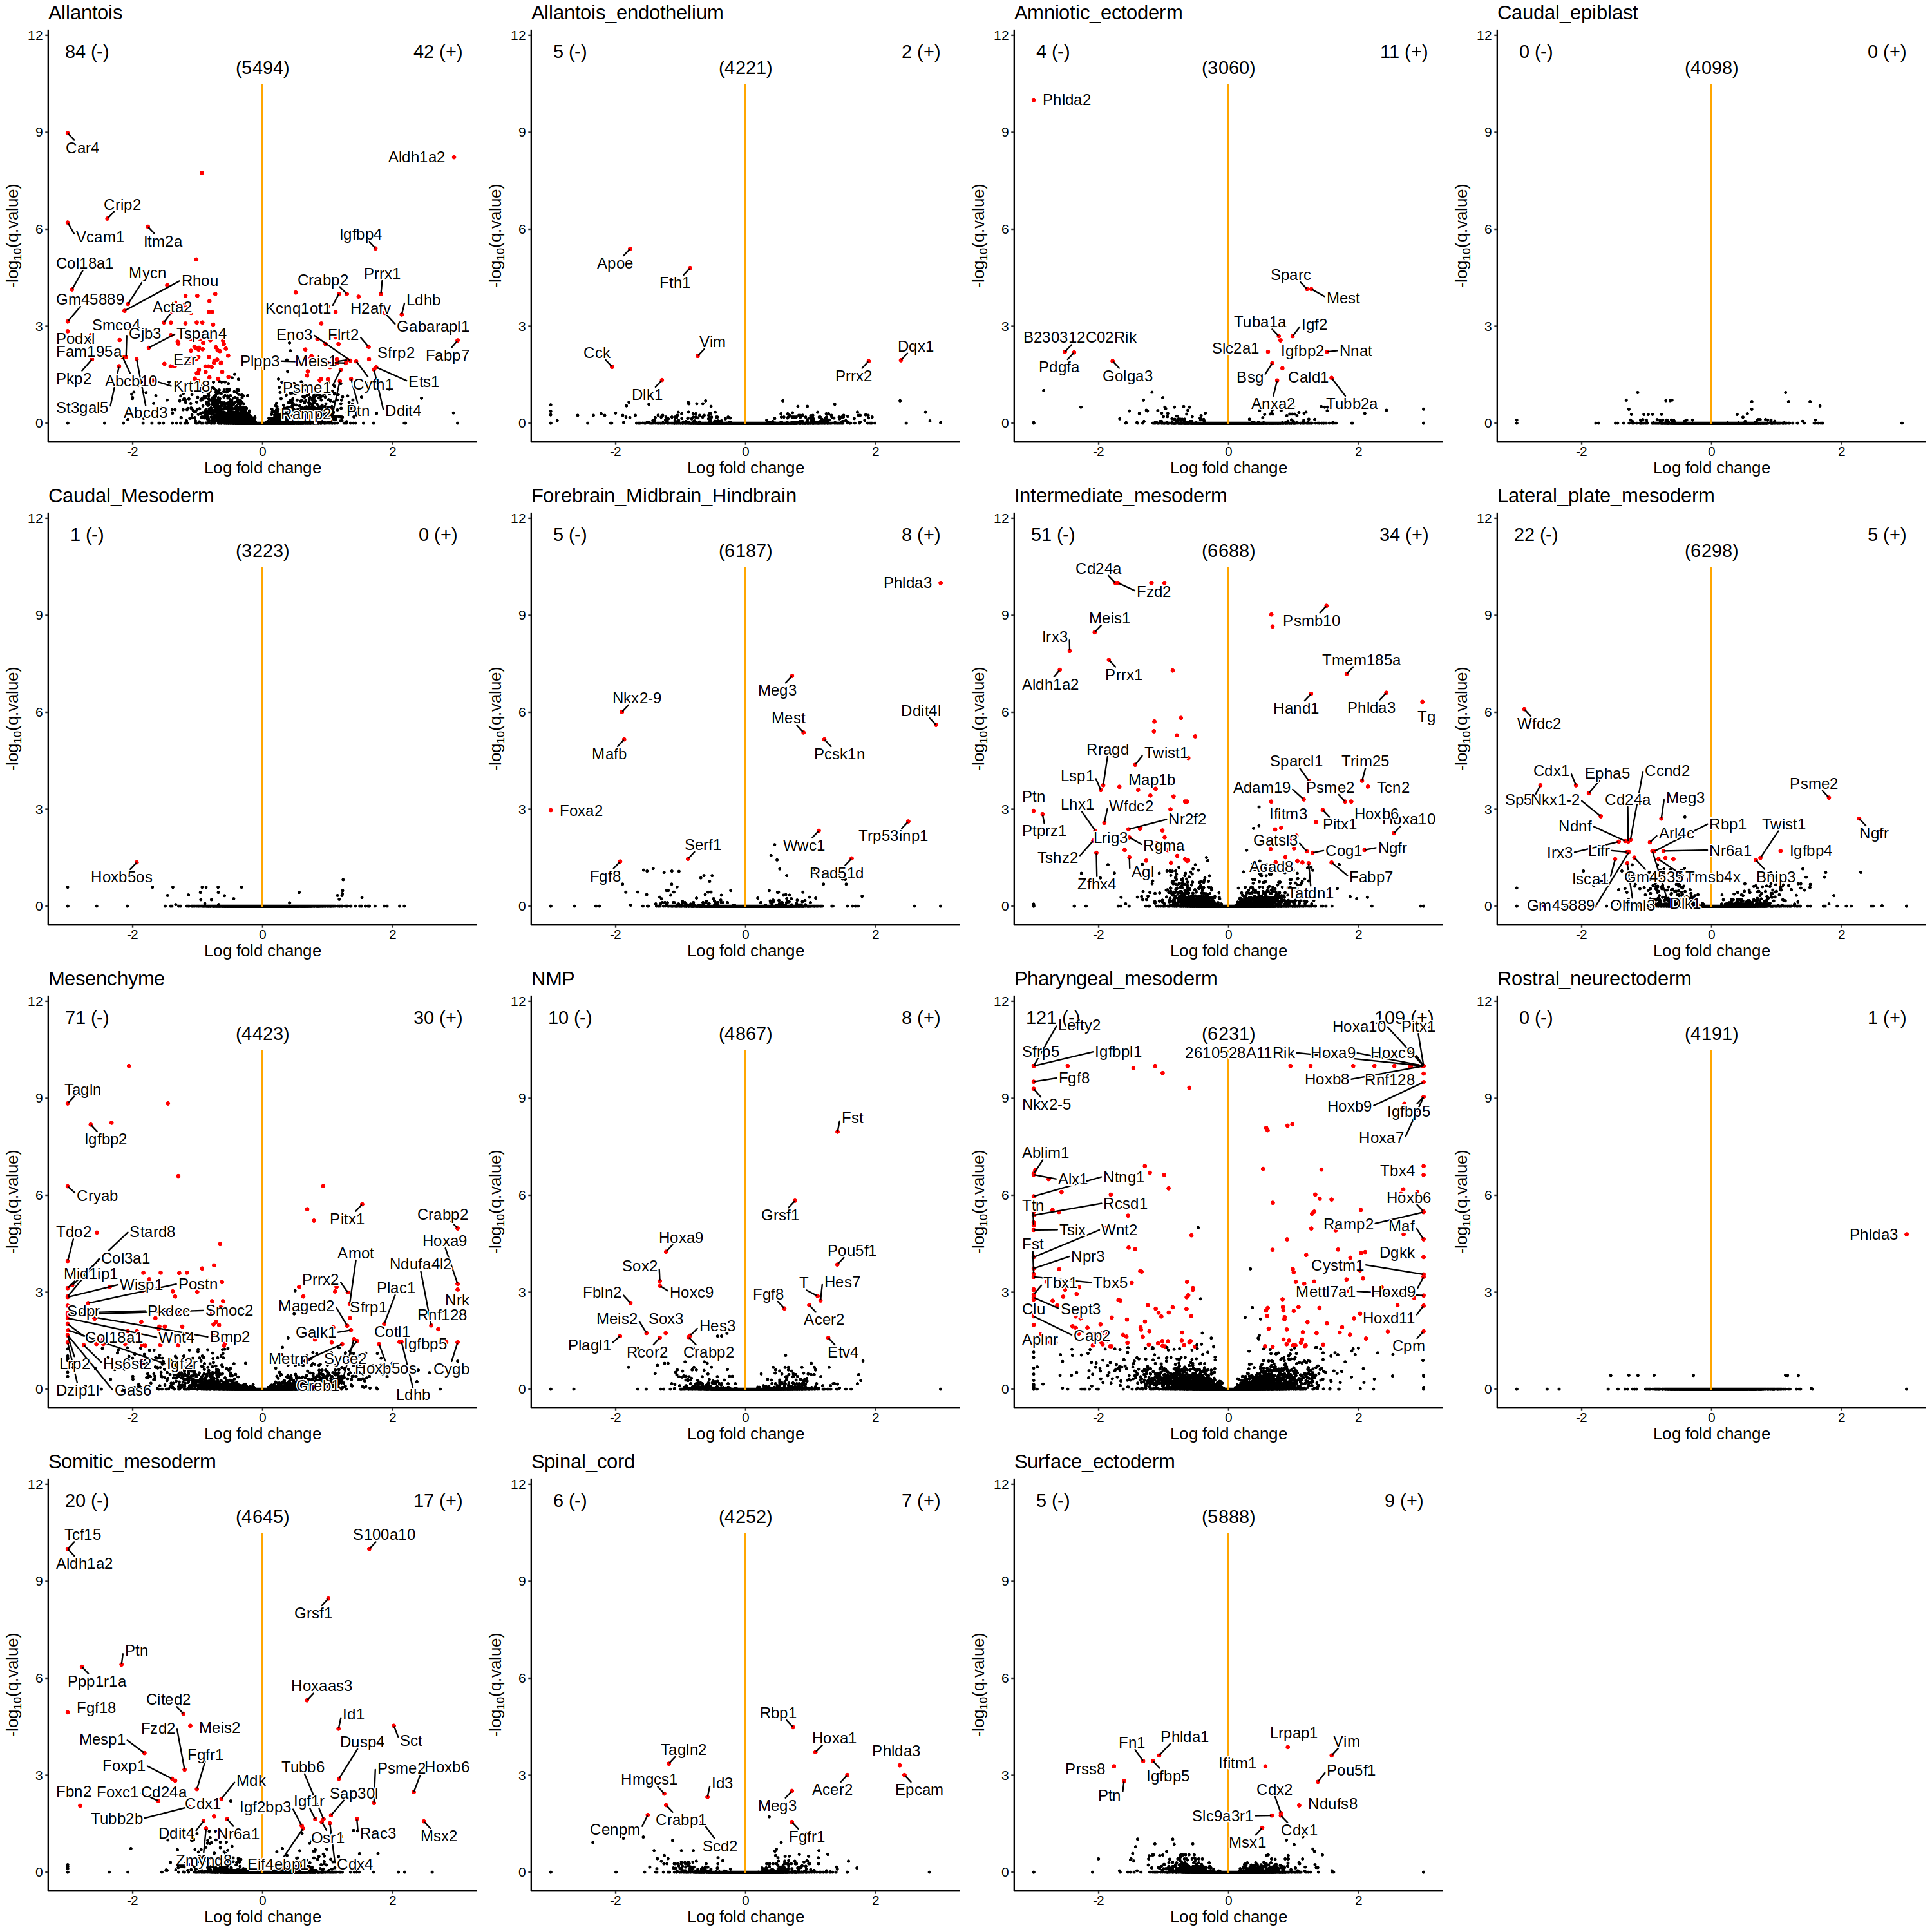

In [37]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

## MiloR

In [38]:
# Load packages
suppressPackageStartupMessages({
    library(dplyr)
    library(data.table)
    library(ggplot2)
    library(SingleCellExperiment)
    library(scater)
    library(scran)
    library(edgeR)
    library(ggrastr)
    library(Seurat)
    library(miloR)
})

here::i_am("MiloR/01_Milo_analysis_manual.ipynb")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [39]:
args$remove_ExE_cells = TRUE
args$batch_correction = "tdTom"

## This is slightly different than original!
args$vars_to_regress = NULL #c('nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA')
args$features = 4000
args$npcs = 40
args$n_neighbors = 20
args$min_dist = 0.4
args$prop = 0.1
args$seed = 12345

### Dimensionality reduction

In [53]:
###############
## Load data ##
###############

# Load metadata
sample_metadata = meta_full %>%
   .[,pool:= stringr::str_replace_all(sample,opts$sample2pool)]

if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata = sample_metadata %>%
    .[!celltype.mapped_mnn%in%c("Visceral_endoderm","ExE_endoderm","ExE_ectoderm","Parietal_endoderm")]
}

# Load RNA expression data as SingleCellExperiment object
sce <- sce_orig[, sample_metadata$cell]
sce = logNormCounts(sce)
# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

[1] "Removing ExE cells..."


In [54]:
##############################
## Dimensionality Reduction ##
##############################

if (args$batch_correction %in% c('tdTom')) {
     source(here::here("mapping/run/mnn/mapping_functions.R"))
     library(batchelor)
   }

 if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
 }

## Feature selection 

# Find HVGs - detection on WT samples only
# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol", "description")] %>%
  .[symbol!="" & ens_id%in%rownames(sce)] %>%
  .[!duplicated(symbol)]

# Imprinted genes
imprint = gene_metadata[c(grep('maternally', gene_metadata$description),
                       grep('paternally', gene_metadata$description)), symbol]
# Other imprinted genes: 
#- Nnat (https://www.genecards.org/cgi-bin/carddisp.pl?gene=NNAT)
#- Grb10 (https://www.genecards.org/cgi-bin/carddisp.pl?gene=GRB10)

genes_keep = rownames(sce)
genes_keep <- genes_keep[grep("^Rik|Rik$|^mt-|^Rps|^Rpl|^Gm",genes_keep,invert=T)] # filter out non-informative genes
genes_keep <- genes_keep[grep("^Hbb|^Hba",genes_keep,invert=T)] # test removing Haem genes 
genes_keep <- genes_keep[!genes_keep %in% c(imprint, 'Grb10', 'Nnat')] # remove imprinted genes
genes_keep <- genes_keep[!genes_keep %in% c("Xist", "Tsix")] # remove Xist & Tsix
genes_keep <- genes_keep[!genes_keep == "tomato-td"] # remove tomato itself
genes_keep <- genes_keep[!genes_keep %in% gene_metadata[chr=="chrY",symbol]] # no genes on y-chr 

sce_wt = sce[genes_keep, sample_metadata[tdTom==FALSE, cell]]
# Find variable genes using Seurat
hvgs = VariableFeatures(FindVariableFeatures(as.Seurat(sce_wt), nfeatures = args$features))

sce_filt <- sce[hvgs,]

In [55]:
## Regress out covariates 
 if (length(args$vars_to_regress)>0) {
   print(sprintf("Regressing out variables: %s", paste(args$vars_to_regress,collapse=" ")))
   logcounts(sce_filt) <- RegressOutMatrix(
     mtx = logcounts(sce_filt), 
     covariates = colData(sce_filt)[,args$vars_to_regress,drop=F]
   )
 }

In [56]:
# PCA and batch correction
if (args$batch_correction=='tdTom') {
    print('batch correcting by tdTom')
    pca <- multiBatchPCA(sce_filt, batch = colData(sce_filt)[[args$batch_correction]], d = args$npcs)
    pca.corrected <- reducedMNN(pca)$corrected
    colnames(pca.corrected) <- paste0("PC",1:ncol(pca.corrected))
    pca.corrected = pca.corrected[match(colnames(sce_filt), rownames(pca.corrected)),]
    reducedDim(sce_filt, "PCA") <- pca.corrected
 } else {
    print('PCA without batch correction')
    sce_filt <- runPCA(sce_filt, ncomponents = args$npcs, ntop=args$features)  
 }

[1] "batch correcting by tdTom"


In [57]:
 pca.dt <- reducedDim(sce_filt,"PCA") %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell")


In [58]:
fwrite(pca.dt, file.path(args$outdir, 'PCA.txt.gz'))

In [59]:
## UMAP
set.seed(args$seed)
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = args$n_neighbors, min_dist = args$min_dist)

# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

In [60]:
fwrite(umap.dt, file.path(args$outdir, 'UMAP.txt.gz'))

In [61]:
# plotting
to.plot <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(sample_metadata, by="cell")

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation ideoms with `aes()`”


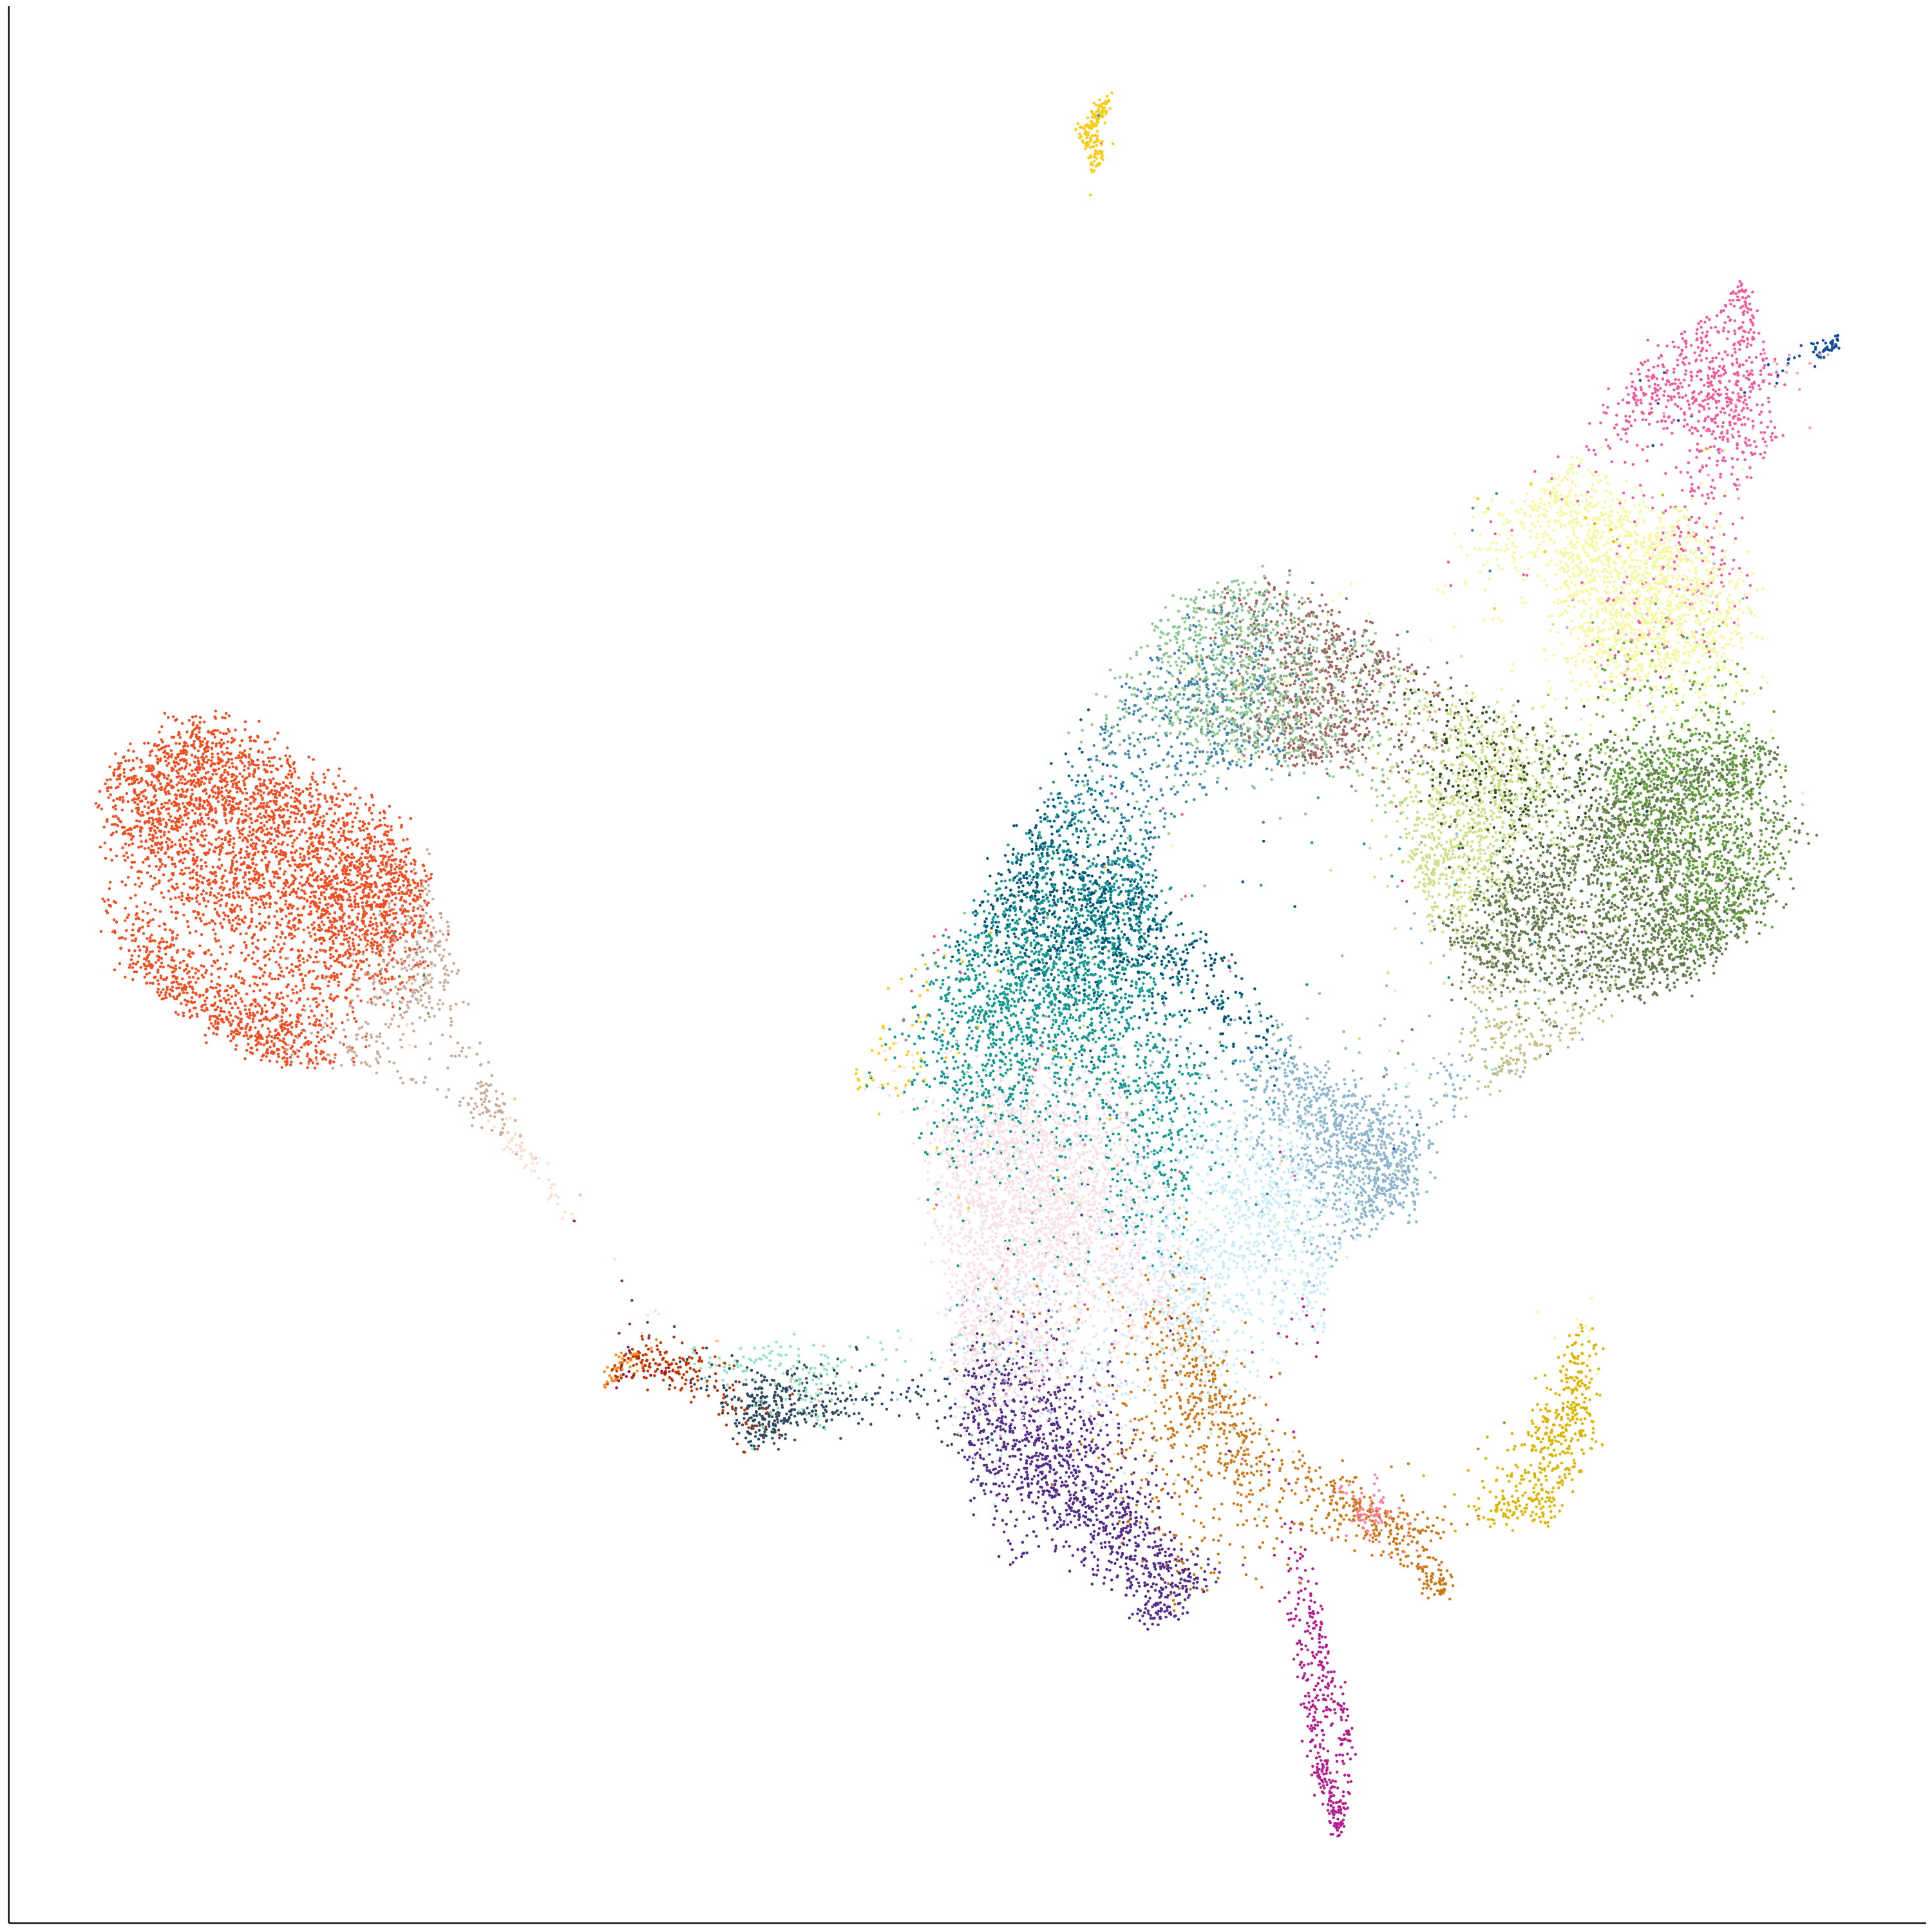

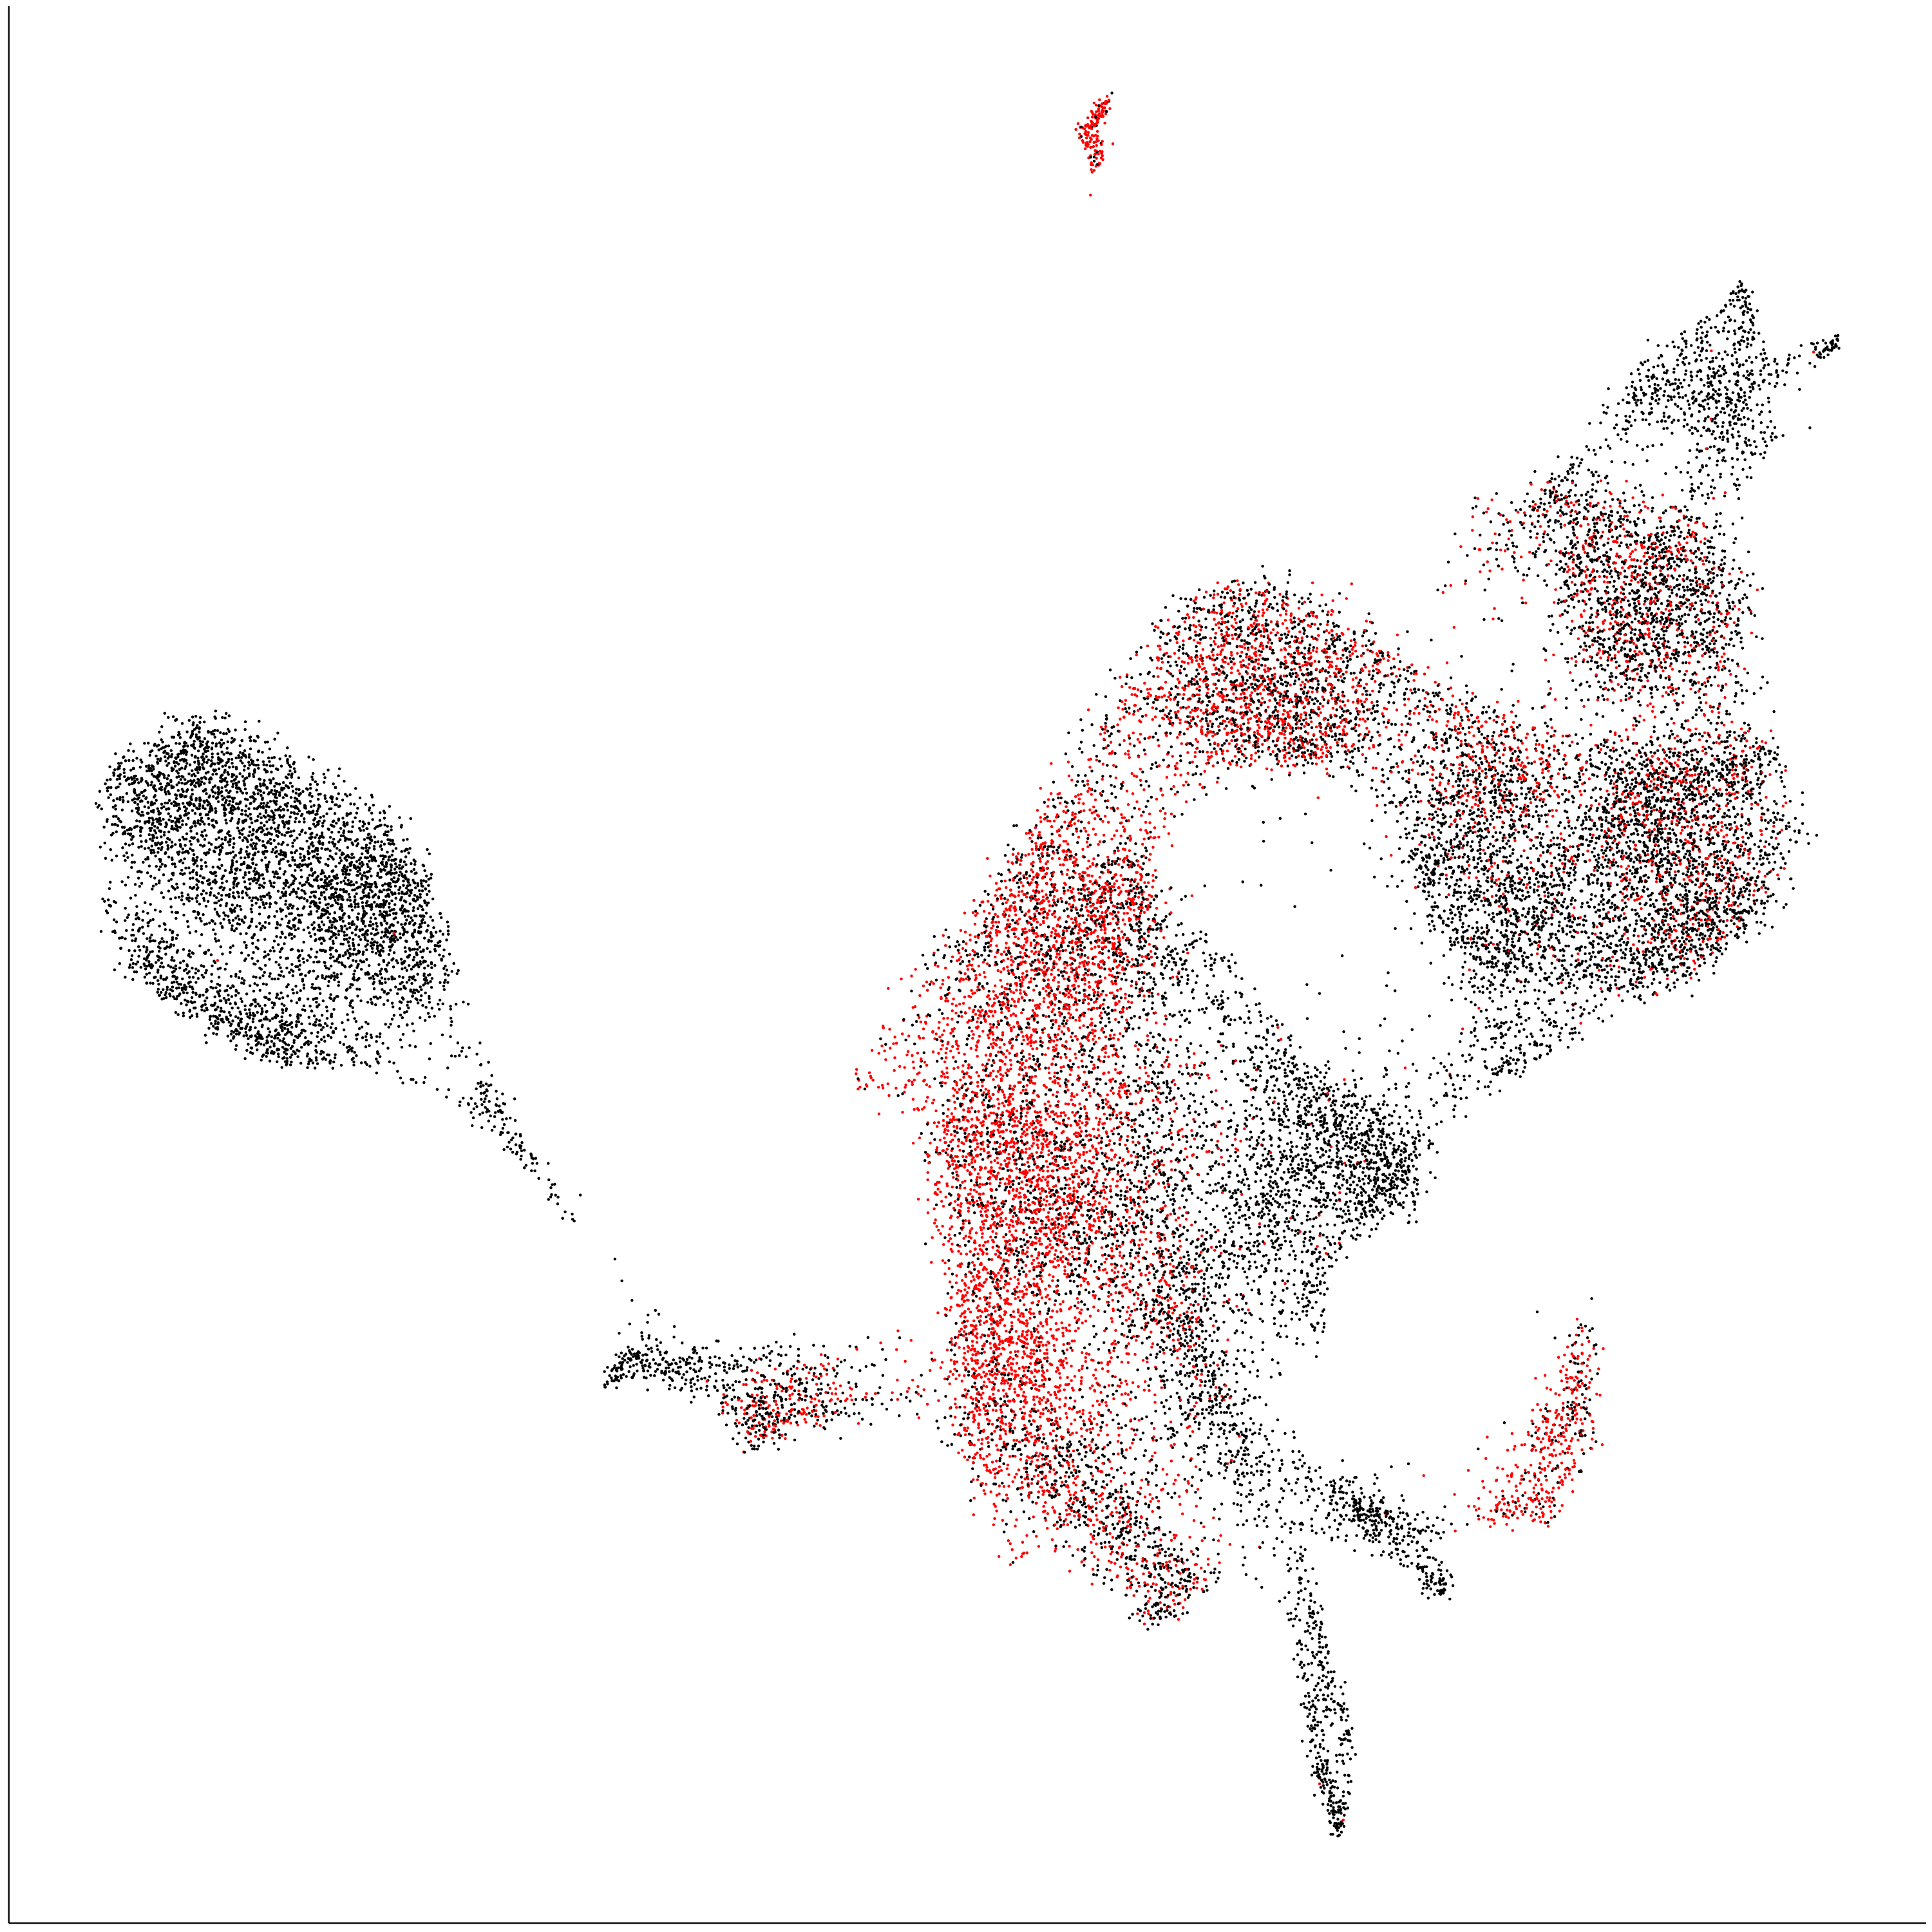

In [62]:
ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype_updated')) +
    geom_point(size=0.2) +
    theme_classic() +
    scale_color_manual(values=c(opts$celltype.colors, opts$celltype_extended.colors)) + 
    theme(
        legend.position="none",
        legend.title=element_blank(),
        axis.title = element_blank(),
        axis.text = element_blank(),
        axis.ticks = element_blank()
    )

ggplot(to.plot, aes_string(x="V1", y="V2", col='tdTom')) +
    geom_point(size=0.2) +
    theme_classic() +
    scale_color_manual(values=opts$tdTom.color) +
    theme(
        legend.position="none",
        legend.title=element_blank(),
        axis.title = element_blank(),
        axis.text = element_blank(),
        axis.ticks = element_blank()
    )

In [63]:
unique(to.plot$celltype_updated)

[1] "Forebrain_Midbrain_Hindbrain"   "Intermediate_mesoderm"         
 [3] "Allantois"                      "Surface_ectoderm"              
 [5] "NMP"                            "Lateral_plate_mesoderm"        
 [7] "Gut"                            "Allantois_endothelium"         
 [9] "Caudal_epiblast"                "Rostral_neurectoderm"          
[11] "Spinal_cord"                    "Amniotic_ectoderm"             
[13] "PGC"                            "Caudal_Mesoderm"               
[15] "Paraxial_mesoderm"              "Somitic_mesoderm"              
[17] "Pharyngeal_mesoderm"            "Caudal_neurectoderm"           
[19] "Def._endoderm"                  "Nascent_mesoderm"              
[21] "YS_endothelium"                 "Erythroid"                     
[23] "Venous_endothelium"             "Embryo_proper_endothelium"     
[25] "Mesenchyme"                     "Blood_progenitors_1"           
[27] "Cardiomyocytes"                 "Blood_progenitors_2"           
[29] "Notochord"                      "YS_mesothelium"                
[31] "Haematoendothelial_progenitors" "Endocardium"                   
[33] "Neural_crest"                   "Primitive_Streak"              
[35] "EMP"                            "Cardiomyocytes_FHF_1"          
[37] "Anterior_Primitive_Streak"      "Epiblast"

### MiloR

In [65]:
head(sample_metadata)

cell,sample,barcode,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,tdTom,idx,⋯,celltype.mapped_mnn,celltype.score_mnn,celltype_extended.mapped_mnn,celltype_extended.score_mnn,stage.mapped_mnn,cellstage.score_mnn,closest.cell_mnn,celltype_updated,pool,variable
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<int>,⋯,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
SLX-20795_SITTA11_HKTG2DRXY#AAACCCAGTTCTCTAT-1,SLX-20795_SITTA11_HKTG2DRXY,AAACCCAGTTCTCTAT-1,5140,31003,1.80,25.11,E8.5,TRUE,1,⋯,Forebrain_Midbrain_Hindbrain,0.9333333,Optic_vesicle,0.4000000,E8.5,0.6666667,cell_132398,Forebrain_Midbrain_Hindbrain,pool4,Forebrain_Midbrain_Hindbrain
SLX-20795_SITTA11_HKTG2DRXY#AAACGCTAGTGATTCC-1,SLX-20795_SITTA11_HKTG2DRXY,AAACGCTAGTGATTCC-1,5119,28276,1.87,27.04,E8.5,TRUE,2,⋯,Intermediate_mesoderm,0.5333333,Intermediate_mesoderm,1.0000000,E8.0,0.5333333,cell_63382,Intermediate_mesoderm,pool4,Intermediate_mesoderm
SLX-20795_SITTA11_HKTG2DRXY#AAACGCTCATGACTCA-1,SLX-20795_SITTA11_HKTG2DRXY,AAACGCTCATGACTCA-1,5032,23751,1.29,22.55,E8.5,TRUE,3,⋯,Allantois,0.7333333,Allantois,0.8000000,E8.25,0.7333333,cell_94241,Allantois,pool4,Allantois
SLX-20795_SITTA11_HKTG2DRXY#AAAGGGCAGTCATGAA-1,SLX-20795_SITTA11_HKTG2DRXY,AAAGGGCAGTCATGAA-1,5562,40272,2.47,30.16,E8.5,TRUE,5,⋯,Surface_ectoderm,0.9333333,Pharyngeal_endoderm,0.4666667,E8.5,0.3333333,cell_20766,Surface_ectoderm,pool4,Surface_ectoderm
SLX-20795_SITTA11_HKTG2DRXY#AAAGGTAAGCCTGCCA-1,SLX-20795_SITTA11_HKTG2DRXY,AAAGGTAAGCCTGCCA-1,5780,33907,2.05,27.02,E8.5,TRUE,6,⋯,Intermediate_mesoderm,0.5333333,Lateral_plate_mesoderm,0.6000000,E7.75,0.4666667,cell_118643,Intermediate_mesoderm,pool4,Intermediate_mesoderm
SLX-20795_SITTA11_HKTG2DRXY#AACAACCTCCTTATAC-1,SLX-20795_SITTA11_HKTG2DRXY,AACAACCTCCTTATAC-1,2614,9167,1.28,32.70,E8.5,TRUE,9,⋯,Intermediate_mesoderm,0.7333333,Presomitic_mesoderm,0.5333333,E8.25,0.5333333,cell_136725,Intermediate_mesoderm,pool4,Intermediate_mesoderm


In [78]:
meta_atlas <- fread(args$atlas_metadata) %>%
  .[stage%in%args$atlas_stages] %>%
  .[,.(cell, umapX, umapY)]

In [83]:
# Add PCA to SCE object
reducedDim(sce,"PCA") = reducedDim(sce_filt,"PCA")

# Add UMAP to SCE object
reducedDim(sce,"UMAP") = reducedDim(sce_filt,"UMAP")

# Add UMAP of Atlas to SCE object
umap.dt <- sample_metadata %>%
    cbind(., meta_atlas[match(sample_metadata$closest.cell_mnn, cell)] %>% .[, cell := NULL])

umap = umap.dt[match(colnames(sce), cell)] %>% tibble::column_to_rownames("cell") %>% as.matrix
reducedDim(sce,"UMAP_atlas") = umap

In [84]:
# Milo arguments
args$prop = 0.1
args$n_neighbors = 20 # smaller --> smaller Nhoods --> higher resolution, but worse statistics


Constructing kNN graph with k:20

Checking valid object

Running refined sampling with reduced_dim



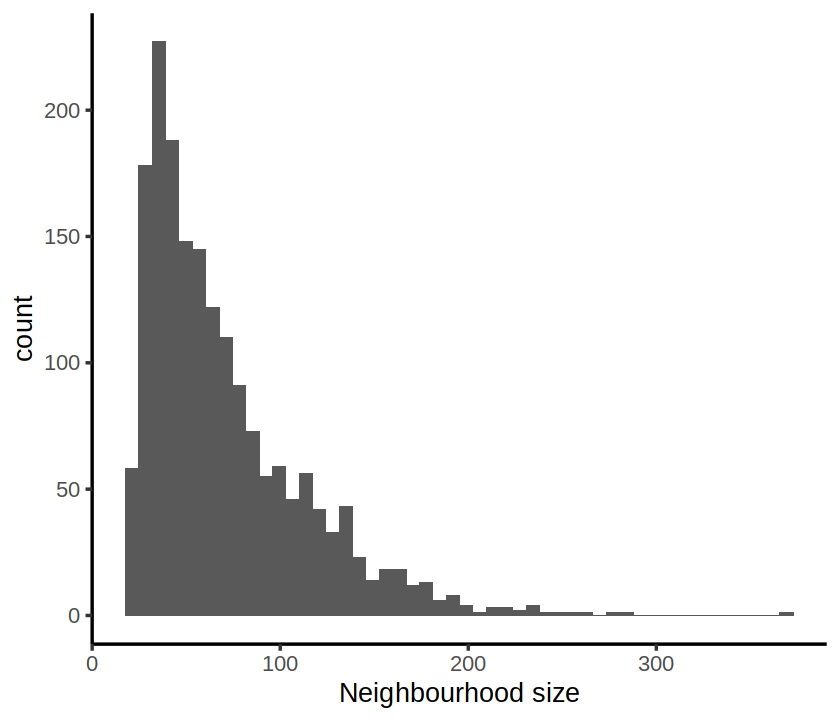

In [85]:
# create object
Milo_sce <- Milo(sce)

colData(Milo_sce)$sample_ko = paste0(colData(Milo_sce)$sample, '_',  colData(Milo_sce)$tdTom)

# Build graph
Milo_sce <- buildGraph(Milo_sce, 
                       k = args$n_neighbors, 
                       d = args$npcs, 
                       reduced.dim = "PCA")

# Identify neighbourhoods from NN-cells
# lower prop for larger datasets
Milo_sce <- makeNhoods(Milo_sce, 
                       prop = args$prop, 
                       k = args$n_neighbors, 
                       d = args$npcs, 
                       refined = TRUE, 
                       reduced_dims = "PCA")

options(repr.plot.width = 7, repr.plot.height=6)
plotNhoodSizeHist(Milo_sce)

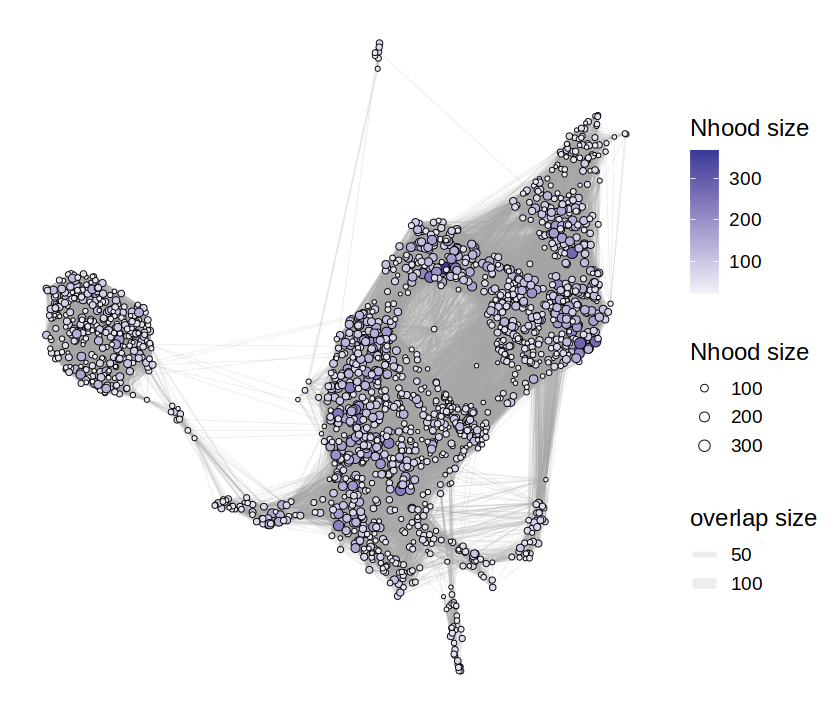

In [86]:
# Build neighbourhood graph
Milo_sce <- buildNhoodGraph(Milo_sce)
plotNhoodGraph(
  Milo_sce,
  layout = "UMAP")

In [87]:
# count cells of different samples per neighbourhood
Milo_sce <- countCells(Milo_sce, meta.data = colData(Milo_sce),  samples = 'sample_ko')

# Calculate Neighbourhood Distances (most time consuming step)
Milo_sce <- calcNhoodDistance(Milo_sce, d=args$npcs, reduced.dim = "PCA")

# Build neighbourhood graph
#Milo_sce <- buildNhoodGraph(Milo_sce)

Checking meta.data validity

Counting cells in neighbourhoods

as(<dgTMatrix>, "dgCMatrix") is deprecated since Matrix 1.5-0; do as(., "CsparseMatrix") instead



In [88]:
saveRDS(Milo_sce, file.path(args$outdir, 'Milo_sce.rds'))

In [89]:
# Embryo design table
embryo_design <- data.frame(colData(Milo_sce))[,c("sample_ko", "sample", 'tdTom', 'pool')]

embryo_design <- distinct(embryo_design)
rownames(embryo_design) <- embryo_design$sample_ko

# Test differential abundance per hood
da_results <- testNhoods(Milo_sce, design = ~ as.factor(pool) + tdTom, design.df = embryo_design, reduced.dim="PCA")

Using TMM normalisation

Performing spatial FDR correction withk-distance weighting



In [90]:
p1 = ggplot(da_results, aes(PValue)) + 
    geom_histogram(bins=50) + 
    theme_bw()

p2 = ggplot(da_results, aes(logFC, -log10(SpatialFDR))) + 
    geom_point() +
    geom_hline(yintercept = 1) + ## Mark significance threshold (10% FDR)
    theme_bw()


## Plot single-cell UMAP
p3 = plotReducedDim(Milo_sce, dimred = "UMAP", colour_by="tdTom_corr", text_by = "celltype.mapped_mnn", 
                          text_size = 3, point_size=0.3, text_colour = "grey30") +
    scale_color_manual(values=opts$tdTom.color, name = 'tdTom') + 
    theme_void() + 
    theme(legend.position='right') +
    guides(fill="none")

## Plot neighbourhood graph
p4 = plotNhoodGraphDA(Milo_sce, da_results, layout="UMAP",alpha=0.05) 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


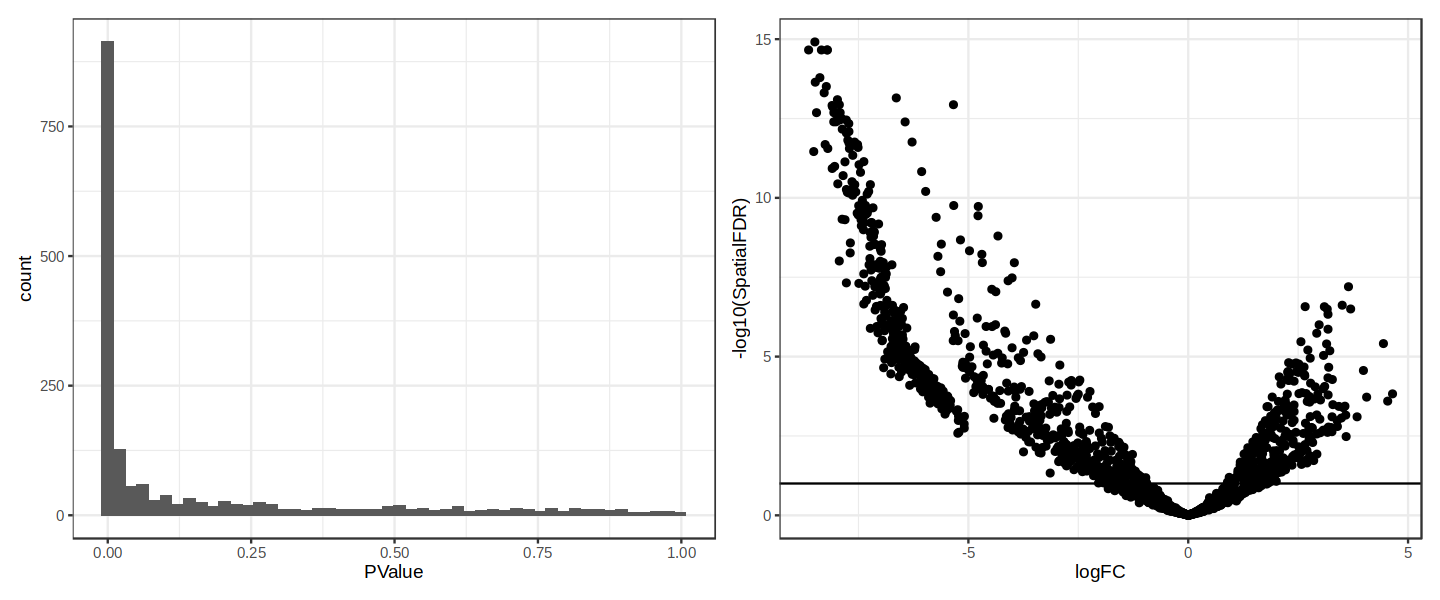

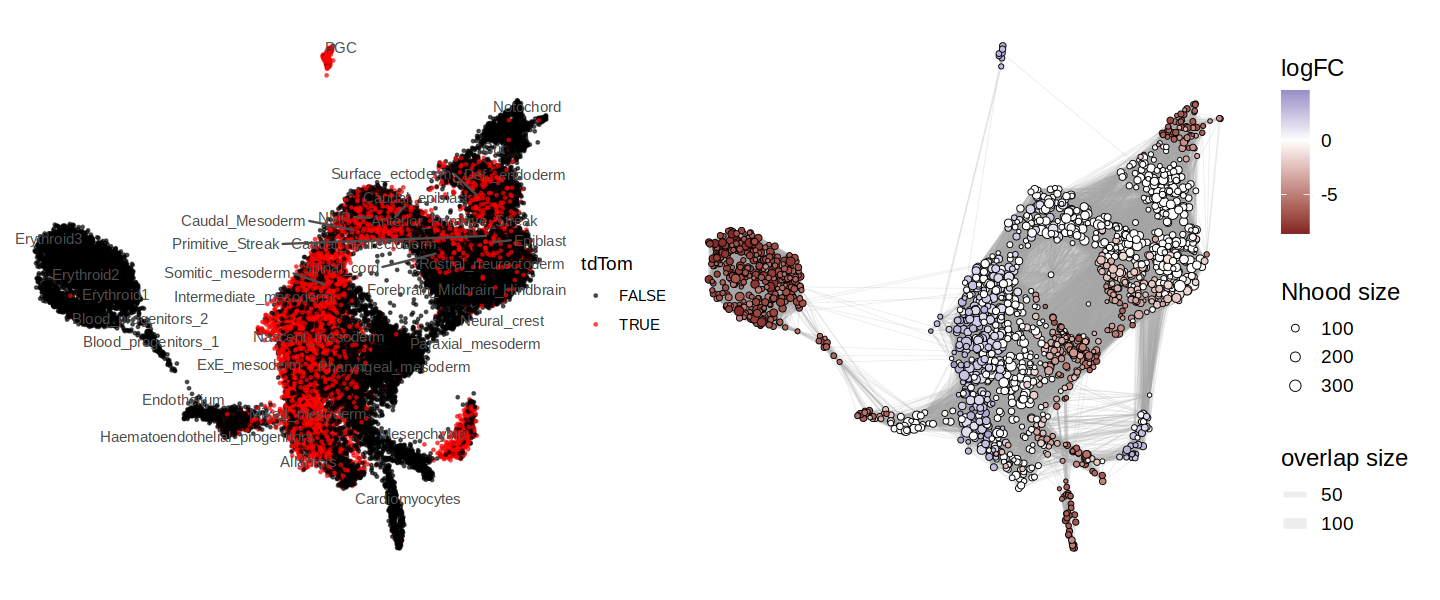

In [91]:
options(repr.plot.width = 12, repr.plot.height=5)

p1 + p2
p3 + p4 

In [119]:
umap = umap.dt[match(colnames(sce), cell)] %>% 
    .[,.(cell, umapX, umapY)] %>% 
    setnames(c('cell', 'x', 'y')) %>% 
    tibble::column_to_rownames("cell") %>% 
    as.matrix
colnames(umap) = NULL
reducedDim(Milo_sce,"UMAP_atlas") = umap

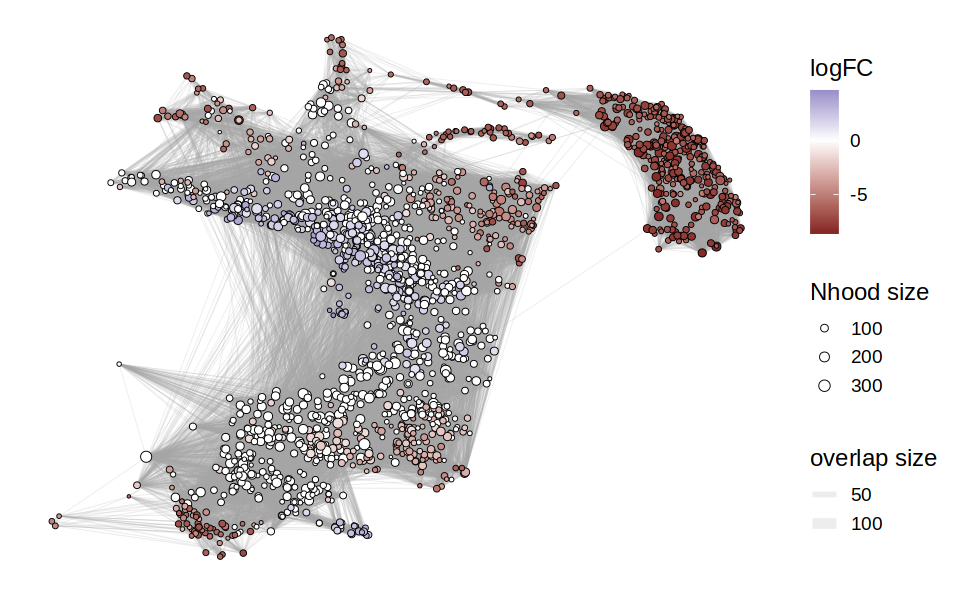

In [120]:
options(repr.plot.width = 8, repr.plot.height=5)
plotNhoodGraphDA(Milo_sce, da_results, layout="UMAP_atlas",alpha=0.05)

In [121]:
# Find Neighbourhood groups
#da_results <- groupNhoods(Milo_sce, da_results, max.lfc.delta = 0.5, overlap = 20)

# Annotate hoods by celltype
da_results <- annotateNhoods(Milo_sce, da_results, coldata_col = "celltype.mapped_mnn")
da_results <- annotateNhoods(Milo_sce, da_results, coldata_col = "celltype_extended.mapped_mnn")
da_results <- annotateNhoods(Milo_sce, da_results, coldata_col = "celltype_updated")

# Annotate 'mixed' hoods when there is not one main celltype
da_results$celltype.mapped_mnn <- ifelse(da_results$celltype.mapped_mnn_fraction < 0.4, "Mixed", da_results$celltype.mapped_mnn)
da_results$celltype_extended.mapped_mnn <- ifelse(da_results$celltype.mapped_mnn_fraction < 0.4, "Mixed", da_results$celltype_extended.mapped_mnn)
da_results$celltype_updated <- ifelse(da_results$celltype_updated_fraction < 0.4, "Mixed", da_results$celltype_updated)

Converting celltype.mapped_mnn to factor...

Converting celltype_extended.mapped_mnn to factor...

Converting celltype_updated to factor...



In [122]:
fwrite(da_results, file.path(args$outdir, 'da_results.txt.gz'))

In [123]:
da_results = fread(file.path(args$outdir, 'da_results.txt.gz'))

In [124]:
summary(is.na(da_results$celltype_updated))

   Mode   FALSE 
logical    1810 

In [125]:
celltype2germlayer = c(
    'Amniotic_ectoderm' = 'ectoderm', 
    'Surface_ectoderm' = 'ectoderm', 
    'Caudal_neurectoderm' = 'ectoderm',
    'Rostral_neurectoderm' = 'ectoderm', 
    'Spinal_cord' = 'ectoderm', 
    'NMP' = 'ectoderm', 
    'Forebrain_Midbrain_Hindbrain' = 'ectoderm', 
    'Neural_crest' = 'ectoderm', 

    'Notochord' = 'endoderm', 
    'Def._endoderm' = 'endoderm', 
    'Gut' = 'endoderm', 

    'PGC' = 'other', 
    'Caudal_epiblast' = 'other', 
    'Mixed' = 'other', 

    'Intermediate_mesoderm' = 'mesoderm', 
    'Nascent_mesoderm' = 'mesoderm',
    'Lateral_plate_mesoderm' = 'mesoderm', 
    'Allantois' = 'mesoderm', 
    'Somitic_mesoderm' = 'mesoderm', 
    'Caudal_Mesoderm' = 'mesoderm', 
    'Mesenchyme' = 'mesoderm', 
    'Pharyngeal_mesoderm' = 'mesoderm', 
    'Paraxial_mesoderm' = 'mesoderm', 
    'Cardiomyocytes' = 'mesoderm', 
    'YS_mesothelium' = 'mesoderm', 
    'Venous_endothelium' = 'mesoderm', 
    'Embryo_proper_endothelium' = 'mesoderm', 
    'Allantois_endothelium' = 'mesoderm', 
    'YS_endothelium' = 'mesoderm', 
    'Blood_progenitors_1' = 'mesoderm', 
    'Blood_progenitors_2' = 'mesoderm',
    'Erythroid' = 'mesoderm'
)

In [126]:
da_results.plot = as.data.table(da_results) %>% copy() %>%
    .[,color := ifelse(SpatialFDR < 0.05, logFC, 0)] %>% .[order(abs(color))] %>% 
    .[,germ_layer := str_to_title(celltype2germlayer[celltype_updated])] %>%
    .[, celltype_updated := factor( gsub('_', ' ', celltype_updated), levels =  gsub('_', ' ', names(celltype2germlayer)))]

In [127]:
head(da_results.plot)

logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,celltype.mapped_mnn,celltype.mapped_mnn_fraction,celltype_extended.mapped_mnn,celltype_extended.mapped_mnn_fraction,celltype_updated,celltype_updated_fraction,color,germ_layer
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<dbl>,<dbl>,<chr>
-0.6290973,10.143448,1.4058827,0.2357930,0.3124343,1,0.3114516,Haematoendothelial_progenitors,0.9264706,Embryo_proper_endothelium,0.5220588,Embryo proper endothelium,0.5147059,0,Mesoderm
1.4443219,8.687238,3.1581892,0.0756029,0.1178650,7,0.1172055,Allantois,1.0000000,Allantois,1.0000000,Allantois,1.0000000,0,Mesoderm
0.3398031,10.577804,0.5156963,0.4727142,0.5606898,9,0.5596977,Caudal_epiblast,0.4787879,Caudal_epiblast,0.5333333,Caudal epiblast,0.4787879,0,Other
-0.5301258,10.918259,1.3723089,0.2414670,0.3178583,10,0.3168757,Rostral_neurectoderm,0.5270270,Ectoderm,0.8468468,Rostral neurectoderm,0.5270270,0,Ectoderm
-1.3831212,9.104616,2.6707998,0.1022626,0.1538615,12,0.1531343,Surface_ectoderm,1.0000000,Surface_ectoderm,0.3103448,Surface ectoderm,0.9827586,0,Ectoderm
-0.7111361,8.842883,0.8071690,0.3689984,0.4549640,13,0.4538061,Surface_ectoderm,0.6410256,Non-neural_ectoderm,0.3076923,Surface ectoderm,0.6410256,0,Ectoderm


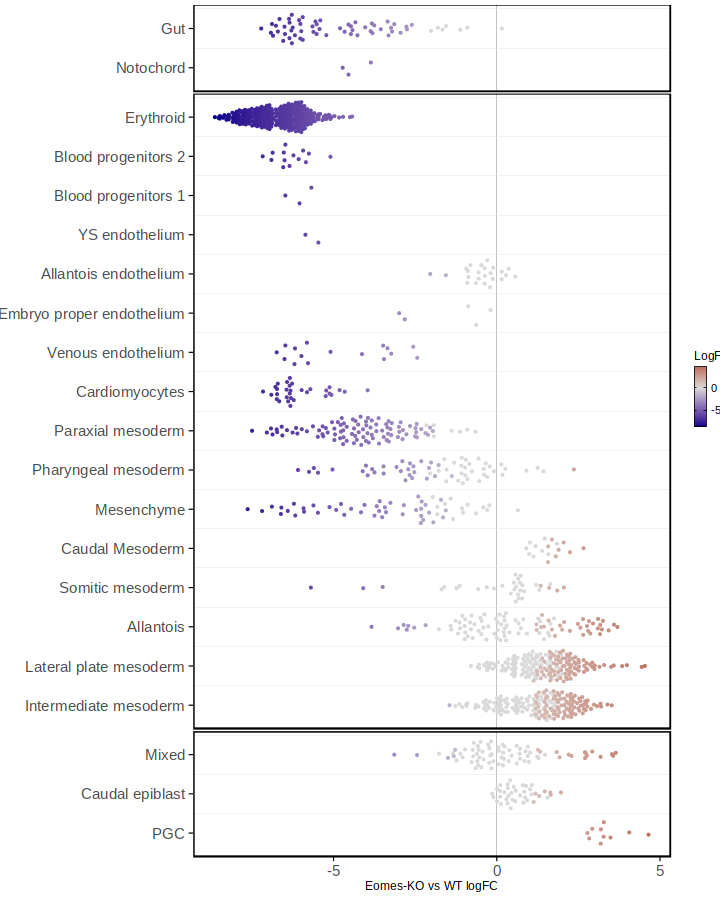

In [129]:
options(repr.plot.width = 6, repr.plot.height=7.5)
p_main = ggplot(da_results.plot[germ_layer != 'Ectoderm'], aes(logFC,celltype_updated, color=color)) + 
    geom_vline(xintercept = 0, color = 'grey50', linewidth = 0.1) +
    ggbeeswarm::geom_quasirandom(size = 0.1) + 
    geom_hline(yintercept=seq(1.5, 20, 1), color = 'grey90', linewidth = 0.1) + 
    scale_color_gradient2(low='darkblue', mid='grey85', high='darkred', name = 'LogFC') + 
    facet_grid(rows = vars(germ_layer), scales='free', space='free') + 
    guides(colour = guide_colourbar(
         barwidth = 0.5, barheight = 2.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    # ggtitle('Differential Abundance') + 
    xlab('Eomes-KO vs WT logFC') + 
    theme_bw() + 
    theme(#axis.text = element_text(size=6, color='black'),
          axis.title.y = element_blank(),
          axis.title.x = element_text(size=7, color='black', vjust = 1.5),
          axis.ticks = element_line(linewidth=0.25, color = 'black'),
          legend.text = element_text(size=6, color='black'),
          legend.title = element_text(size=7, color='black'),
          plot.title = element_text(size=8, color='black', hjust = 0.5, vjust = -1),
          panel.border = element_rect(color='black', linewidth=0.5),
          panel.spacing = unit(0.5, "mm"),
          legend.position = c(1.05, 0.55), # Position legend outside the plot (right and center vertically)
          legend.justification = c("left", "center"), # Justify legend to the center vertically and to the left horizontally
          legend.box.margin = margin(0, 0, 0, 0), # Adjust the margins around the legend box
          legend.margin = margin(0, 0, 0, 0), # Adjust the margins inside the legend box
          plot.margin = margin(3,30,3,3),
          panel.grid = element_blank(), 
          # legend.position='right',
          strip.background=element_blank(),
          strip.text.y = element_blank()) #_text(size=15, color='black', angle=0, hjust=0))
p_main

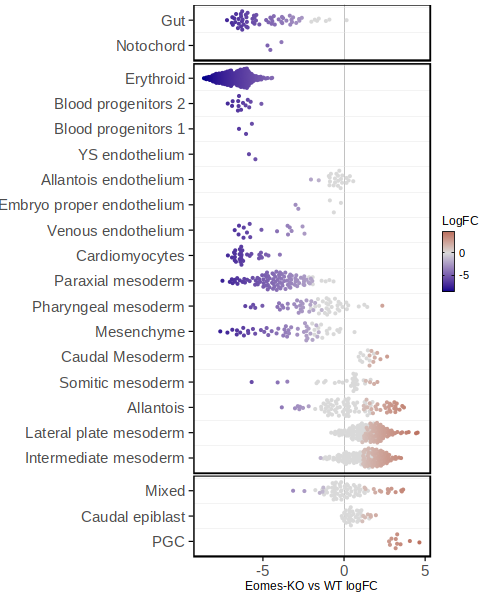

In [130]:
options(repr.plot.width = 4, repr.plot.height=5)
p_main